# Worked example: one HPWREN camera, one night

This notebook calibrates one camera from start to finish: **High Point West** on Palomar
Mountain (`hp-w-mobo-c`). It uses 90 minutes of its night frames from 11 September 2026, then
checks the result four ways: against a second night, against an optical centre fitted from
many nights, against landmarks in a daytime frame, and against ridges from a terrain model.

Everything here runs on the public library API. The HPWREN package only fetches the frames
and supplies the camera table.

**Data:** camera frames from [HPWREN](https://www.hpwren.ucsd.edu/), from its public CDN.

**To run it:**

```sh
pip install "star-calibration[opencv] @ git+https://github.com/rharnish/star-calibration" matplotlib jupyter
```

It downloads about 45 MB of frames and 125 MB of terrain model into `$HPWREN_CACHE` (default
`~/.cache/hpwren`) and reuses whatever is already there. The CDN keeps only about the last 89 days of frames. If
the dates below have expired, set `DAY`, `DAY2` and `DAY_TIME` to recent ones. The numbers
will differ from the text, but the steps are the same.

In [1]:
%config InlineBackend.figure_format = "jpeg"
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np

from star_calibration import fisheye, overlay
from star_calibration import pole as POLE
from star_calibration.cross_night import disagreement
from star_calibration.intrinsics import lookup
from star_calibration.solve import Night, solve_wide
from star_calibration.tracks import clean, collect
from star_calibration.hpwren import HERE, cache_dir, cameras, intrinsics_path, ledger_path, nights

CAM = "hp-w-mobo-c"
DAY = "20260911"        # the night to solve: Q1 is 00:00-02:59 local time; we use the first 90 min
DAY2 = "20260905"       # a second night, to check the first against
DAY_TIME = "20260911"   # a daytime block (Q4, 09:00-11:59 local) for the landmark check


def show(img_bgr, title=None, width=12):
    h, w = img_bgr.shape[:2]
    plt.figure(figsize=(width, width * h / w))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title, loc="left")
    plt.show()

## 1. The published camera record

HPWREN's camera table gives each camera's site precisely, and gives a nominal heading and
field of view. That is the starting point. The solver measures corrections to it:
`d_az`, `d_pitch` and `d_roll`, plus the lens.

In [2]:
cam = cameras()[CAM]
cam

{'site': 'hp',
 'lat': 33.36302,
 'lon': -116.83622,
 'elev': 1871,
 'az': 270,
 'fov': 90,
 'imager': 'color',
 'roll': 0.0,
 'pitch': 0.0,
 'yaw': 0.0,
 'agl': 20.0}

## 2. Frames

`nights.fetch` downloads one block from the CDN, at about one frame a minute. The library
doesn't care where frames come from. It takes `(epoch, offset_s, jpeg_bytes)` tuples in
time order. `offset_s` counts from a reference epoch `t0`, here the middle frame.

In [3]:
print(nights.fetch(CAM, DAY, q=1, n_frames=90))   # (camera, day, frames on disk, frames listed)


def read_block(day, q=1):
    d = cache_dir() / "nights" / CAM / f"{day}_Q{q}"
    paths = sorted(d.glob("*.jpg"), key=lambda p: int(p.stem))   # files are named by epoch
    epochs = [int(p.stem) for p in paths]
    t0 = epochs[len(epochs) // 2]
    return t0, [(e, e - t0, p.read_bytes()) for e, p in zip(epochs, paths)]


t0, frames = read_block(DAY)
print(len(frames), "frames, t0 =", t0)

('hp-w-mobo-c', '20260911', 90, 90)
90 frames, t0 = 1789112731


## 3. Tracks

`collect` finds point sources in every frame where the sun is at least 8° below the horizon,
and links them from frame to frame. It keeps only what persists and moves. Hot pixels stay
put, and stars drift at the sidereal rate. `clean` then removes anything that isn't a single
star: tracks the linker passed from one star to another, cloud texture, and HPWREN's
burned-in clock in the top 60 rows.

In [4]:
linked, decoded = collect(frames, lat=cam["lat"], lon=cam["lon"], max_gap_s=300)
tracks, counts = clean(linked, banner_px=60)
H, W = next(iter(decoded.values()))[1].shape[:2]
print(counts)
print(f"frame size {W} x {H}")

frames: 90/90 frames dark enough (sun el <= -8.0)


  1159 raw tracks -> 77 moving, persistent tracks
{'linked': 77, 'wandering': 7, 'split': 17, 'banner': 0, 'duplicate': 0, 'kept': 72}
frame size 3072 x 2048


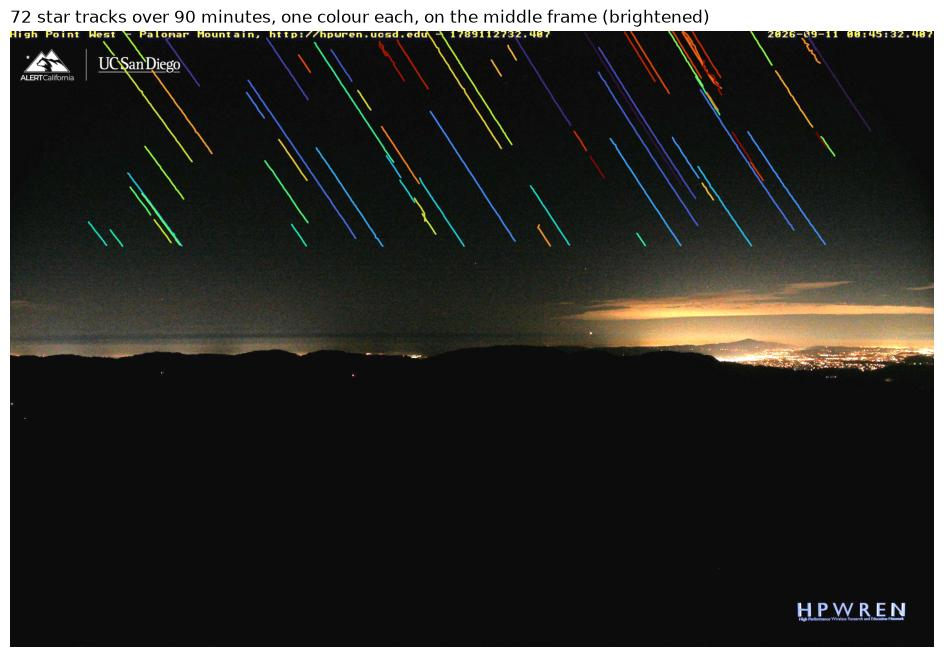

In [5]:
mid = sorted(decoded)[len(decoded) // 2]
frame = decoded[mid][1]
canvas = cv2.convertScaleAbs(frame, alpha=2.0, beta=10)
cmap = plt.get_cmap("turbo")
for i, t in enumerate(tracks):
    pts = np.array([t[o][:2] for o in sorted(t)], np.int32)
    r, g, b, _ = cmap(i / max(1, len(tracks) - 1))
    cv2.polylines(canvas, [pts], False, (int(b * 255), int(g * 255), int(r * 255)), 4, cv2.LINE_AA)
show(canvas, f"{len(tracks)} star tracks over 90 minutes, one colour each, on the middle frame (brightened)")

## 4. The celestial pole, before any star is named

Every star turns about the celestial pole at the sidereal rate. For a star in direction
*d*, the motion is *ḋ = ω (p × d)*, which is linear in the pole *p*. One least-squares solve
over every track sample therefore gives the pole in camera coordinates. It needs no catalog
and no search.

The fit is told the sidereal rate, so the pole's length |p| comes out at 1 only when the
pixel-to-angle map is right. That makes |p| a measurement of the lens. `lens_scale` finds
the lens scale at which |p| = 1.

In [6]:
k0 = fisheye.initial_k(cam, W)   # nameplate scale: half the frame width spans half the fov
fit = POLE.estimate(tracks, W, H, fisheye.K_RATIO * k0, fisheye.K1)
print(f"pole in camera coordinates {np.round(fit['p_hat'], 3)}, |p| = {fit['norm']:.4f} "
      f"under the shared lens ({fisheye.K_RATIO}x nameplate)")
print(f"inliers {fit['n_inliers']}/{fit['n']} track samples")
lens = POLE.lens_scale(tracks, W, H, k0, fisheye.K1)
print(f"lens scale from the trails alone: {lens['k_ratio']:.4f}x nameplate")

pole in camera coordinates [ 0.833  0.553 -0.008], |p| = 1.0025 under the shared lens (0.886x nameplate)
inliers 1922/2053 track samples


lens scale from the trails alone: 0.8878x nameplate


The pole fixes two of the three angles. The solver then scans the remaining turn about the
pole, refines the pose with catalog stars matched to whole tracks, and fits the lens.

## 5. Solve

The `Night` needs the frame size (`W`, `H`). Its defaults are HPWREN's 3072 × 2048, so frames
of any other size must say so. The camera record can also carry the optical centre `cx`,
`cy`: pixels right and down from the frame's middle. HPWREN's are fitted from all of a
camera's nights at once and ship in `hpwren/intrinsics.json`.

In [7]:
cx, cy = lookup(json.loads(intrinsics_path().read_text()), CAM, W, H, t0)
cam_c = {**cam, "cx": cx, "cy": cy}
night = Night(camera=CAM, cam=cam_c, t0=t0, tracks=tracks, W=W, H=H, label=f"{CAM} {DAY} Q1")
r = solve_wide(night)

print(f"optical centre ({cx}, {cy}) px from the middle")
print(f"{r['status']}: {r['n_stars']} stars, median residual {r['median_px']:.2f} px, "
      f"rms {r['rmse_px']:.2f} px, found by {r['found_by']}")
p = r["pose"]
print(f"d_az {p['d_az']:+.3f} deg   d_pitch {p['d_pitch']:+.3f} deg   d_roll {p['d_roll']:+.3f} deg")
print(f"lens {p['k_ratio']:.4f}x nameplate, k1 {p['k1']:+.4f}")
print(f"heading {(cam['az'] + p['d_az']) % 360:.2f} deg against the table's {cam['az']}")

optical centre (-7.0, -2.2) px from the middle
solved: 38 stars, median residual 0.57 px, rms 6.43 px, found by pole
d_az -0.287 deg   d_pitch -0.378 deg   d_roll -0.140 deg
lens 0.8881x nameplate, k1 -0.0764
heading 269.71 deg against the table's 270


The acceptance test needs at least 8 stars, a median residual under 3 px, and a lens scale in
a plausible band. The rms is larger because it counts every track sample, including the few
that the robust fit sets aside. A median residual of about half a pixel, over dozens of stars spread across
the frame, is typical of a good night.

`overlay.draw` puts the solve on its own frame. Matched tracks are thick green, with each
star's predicted arc under the fitted pose in thin magenta inside it. Orange shows the same
stars under the published pose, and yellow arrows run from where the published pose puts
each star to where the fit has it.

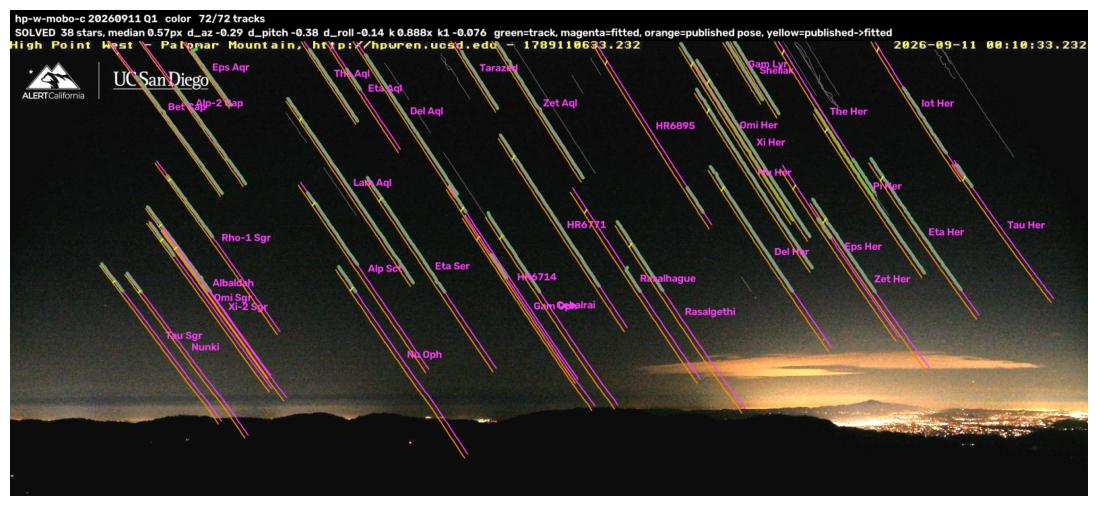

In [8]:
ref = overlay.reference_offset(r, night)
nearest = min(decoded, key=lambda o: abs(o - ref))
show(overlay.draw(r, night, decoded[nearest][1]), width=14)

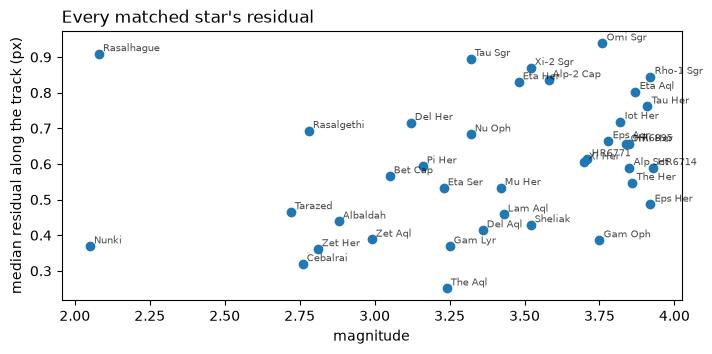

In [9]:
names = sorted(r["per_star_px"], key=lambda n: r["mags"][n])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter([r["mags"][n] for n in names], [r["per_star_px"][n] for n in names])
for n in names:
    ax.annotate(n, (r["mags"][n], r["per_star_px"][n]), fontsize=7, alpha=0.7,
                xytext=(3, 2), textcoords="offset points")
ax.set_xlabel("magnitude")
ax.set_ylabel("median residual along the track (px)")
ax.set_title("Every matched star's residual", loc="left")
plt.show()

## 6. Why the optical centre comes from many nights

Solve the same tracks again with the centre at the frame's middle:

In [10]:
r0 = solve_wide(Night(camera=CAM, cam={**cam, "cx": 0.0, "cy": 0.0}, t0=t0, tracks=tracks, W=W, H=H))
for label, x in (("centre from intrinsics.json", r), ("centre at the frame's middle", r0)):
    q = x["pose"]
    print(f"{label:30s} {x['n_stars']} stars, {x['median_px']:.3f} px   "
          f"d_az {q['d_az']:+.3f}  d_pitch {q['d_pitch']:+.3f}  d_roll {q['d_roll']:+.3f}")

centre from intrinsics.json    38 stars, 0.566 px   d_az -0.287  d_pitch -0.378  d_roll -0.140
centre at the frame's middle   38 stars, 0.567 px   d_az -0.039  d_pitch -0.463  d_roll -0.160


Both fit equally well, yet the headings differ by about a quarter of a degree. One night
can't separate a small shift of the optical centre from a small turn of the camera: moving
the centre 7 px sideways and turning the camera by the angle 7 px subtends both slide the
stars across the frame. Across nights the sky moves differently against the camera, which
breaks the tie. That is why `intrinsics.py` fits each camera's centre jointly from all of its
nights:

In [11]:
row = next(x for x in json.loads(intrinsics_path().read_text()) if x["camera"] == CAM)
print(f"centre ({row['cx']}, {row['cy']}) px, fitted from {row['n_nights']} nights and "
      f"{row['n_stars']} star matches")

centre (-7.0, -2.2) px, fitted from 7 nights and 282 star matches


## 7. A second night

The strongest internal check is a repeat measurement. A different night has a different
sky, different stars and different track positions. If the pose is real, it comes back
the same.

In [12]:
print(nights.fetch(CAM, DAY2, q=1, n_frames=90))
t0b, frames_b = read_block(DAY2)
linked_b, decoded_b = collect(frames_b, lat=cam["lat"], lon=cam["lon"], max_gap_s=300)
tracks_b, _ = clean(linked_b, banner_px=60)
cx_b, cy_b = lookup(json.loads(intrinsics_path().read_text()), CAM, W, H, t0b)
r2 = solve_wide(Night(camera=CAM, cam={**cam, "cx": cx_b, "cy": cy_b}, t0=t0b, tracks=tracks_b, W=W, H=H))

shared = set(r["matches"]) & set(r2["matches"])
sep, droll = disagreement(cam, r["pose"], r2["pose"])
print(f"{DAY}: {r['n_stars']} stars    {DAY2}: {r2['n_stars']} stars    {len(shared)} in common")
print(f"boresights {sep:.3f} deg apart, roll differs by {droll:.3f} deg")

('hp-w-mobo-c', '20260905', 90, 90)


frames: 90/90 frames dark enough (sun el <= -8.0)


  1345 raw tracks -> 82 moving, persistent tracks


20260911: 38 stars    20260905: 42 stars    33 in common
boresights 0.038 deg apart, roll differs by 0.003 deg


The shipped ledger holds every night this camera has solved:

In [13]:
from datetime import datetime, timezone

rows = [e for e in json.loads(ledger_path().read_text()) if e["camera"] == CAM]
print(f"{'night (UTC)':12s} {'stars':>5s} {'px':>5s} {'d_az':>7s} {'d_pitch':>8s} {'d_roll':>7s} {'k':>7s}")
for e in sorted(rows, key=lambda e: e["epoch"]):
    day = datetime.fromtimestamp(e["epoch"], timezone.utc).strftime("%Y-%m-%d")
    print(f"{day:12s} {e['n_stars']:5d} {e['median_px']:5.2f} {e['d_az']:+7.3f} "
          f"{e['d_pitch']:+8.3f} {e['d_roll']:+7.3f} {e['k_ratio']:7.4f}")
az = [e["d_az"] for e in rows]
print(f"\nheading spread over {len(rows)} nights: {max(az) - min(az):.3f} deg")

night (UTC)  stars    px    d_az  d_pitch  d_roll       k
2026-08-29      44  0.84  -0.284   -0.367  -0.140  0.8896
2026-09-01      40  0.66  -0.268   -0.366  -0.147  0.8886
2026-09-02      39  0.74  -0.244   -0.353  -0.150  0.8888
2026-09-03      40  0.70  -0.257   -0.356  -0.147  0.8888
2026-09-04      39  0.72  -0.263   -0.359  -0.142  0.8888
2026-09-05      42  0.76  -0.256   -0.356  -0.137  0.8889
2026-09-11      38  0.57  -0.287   -0.378  -0.140  0.8881

heading spread over 7 nights: 0.043 deg


## 8. A check that doesn't use the stars

Agreement between nights shows the measurement is repeatable. It doesn't show that it's
right: a systematic error, such as a wrong sky model, would repeat too. For that, take a
daytime frame and project known landmarks through the solved pose. Nothing in the image is
fitted.

Two landmarks are in this camera's view:

- **The Hale Telescope dome** at Palomar Observatory, 2.7 km away (33.35639°N, 116.86472°W,
  base 1713 m, aimed at 20 m up the dome). It's close, so its coordinates limit the test:
  10 m of position error is 0.2° from here.
- **Santiago Peak**, 75 km away, from HPWREN's own site list (`sites.js`). At that distance
  10 m is 0.008°, so this is the sharper test.

The elevation angle includes Earth's curvature and standard refraction (k = 0.13).

('hp-w-mobo-c', '20260911', 3, 3)


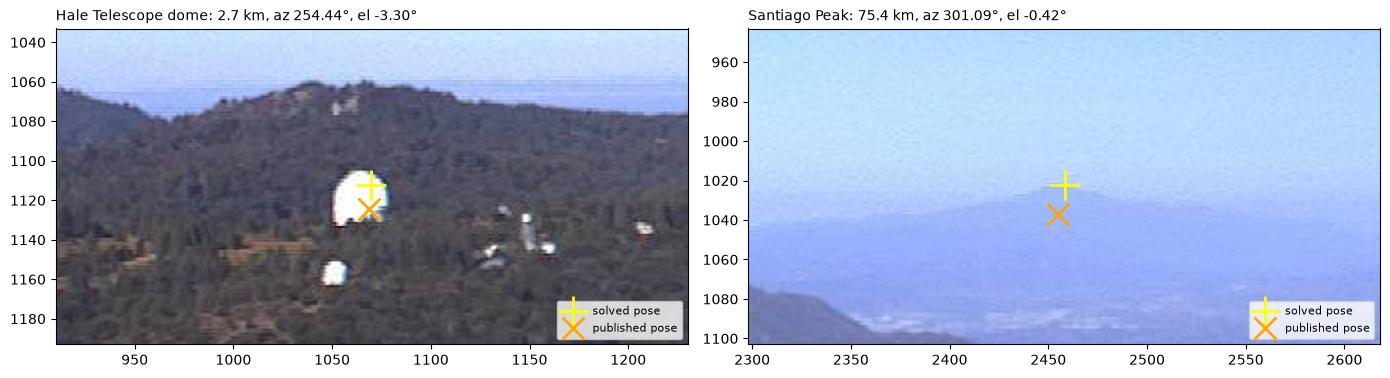

In [14]:
print(nights.fetch(CAM, DAY_TIME, q=4, n_frames=3))
day_paths = sorted((cache_dir() / "nights" / CAM / f"{DAY_TIME}_Q4").glob("*.jpg"))
day = cv2.imread(str(day_paths[0]))

txt = (HERE / "sites.js").read_text()
sites = json.loads(txt[txt.index("{"):txt.rindex("}") + 1])
R_EARTH = 6371000.0


def az_el(lat1, lon1, h1, lat2, lon2, h2, k_refr=0.13):
    # Bearing and apparent elevation from one point to another, with curvature and refraction.
    p1, p2, dl = math.radians(lat1), math.radians(lat2), math.radians(lon2 - lon1)
    az = math.degrees(math.atan2(math.sin(dl) * math.cos(p2),
                                 math.cos(p1) * math.sin(p2) - math.sin(p1) * math.cos(p2) * math.cos(dl))) % 360
    d = R_EARTH * math.acos(min(1.0, math.sin(p1) * math.sin(p2) + math.cos(p1) * math.cos(p2) * math.cos(dl)))
    el = math.degrees(math.atan2(h2 - h1 - d * d * (1 - k_refr) / (2 * R_EARTH), d))
    return az, el, d


def to_pixel(c, az, el, pose=None):
    # Where a direction lands: through the solved pose and lens, or the published pose and shared lens.
    if pose is None:
        c = {**c, "cx": 0.0, "cy": 0.0}
        kw = dict(k_scale=fisheye.K_RATIO * fisheye.initial_k(c, W), k1=fisheye.K1)
    else:
        kw = dict(d_az=pose["d_az"], d_pitch=pose["d_pitch"], d_roll=pose["d_roll"],
                  k_scale=pose["k_ratio"] * fisheye.initial_k(c, W), k1=pose["k1"])
    x, y = fisheye.project_fisheye(c, np.array([az]), np.array([el]), W, H, **kw)
    return float(x[0] * W), float(y[0] * H)


h_cam = cam["elev"] + cam["agl"]   # the camera sits agl metres up its mast
landmarks = {
    "Hale Telescope dome": (33.35639, -116.86472, 1713 + 20),
    "Santiago Peak": (sites["stgo"]["lat"], sites["stgo"]["long"], sites["stgo"]["elev"]),
}
fig, axes = plt.subplots(1, len(landmarks), figsize=(14, 4))
for ax, (name, (lat, lon, h)) in zip(axes, landmarks.items()):
    az, el, d = az_el(cam["lat"], cam["lon"], h_cam, lat, lon, h)
    xs, ys = to_pixel(cam_c, az, el, r["pose"])
    xp, yp = to_pixel(cam, az, el)
    X, Y = int(round(xs)), int(round(ys))
    crop = day[Y - 80:Y + 80, X - 160:X + 160]
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB), extent=(X - 160, X + 160, Y + 80, Y - 80))
    ax.plot(xs, ys, "+", color="yellow", ms=22, mew=2, label="solved pose")
    ax.plot(xp, yp, "x", color="orange", ms=16, mew=2, label="published pose")
    ax.set_title(f"{name}: {d / 1000:.1f} km, az {az:.2f}°, el {el:+.2f}°", loc="left", fontsize=10)
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

The yellow cross lands on the dome and on Santiago Peak's summit, within a few pixels. A
pixel near the frame's centre is about 0.03°. For this camera the published pose is already
close: its cross sits 12–15 px lower, mostly the 0.4° pitch the table can't express,
because its pitch is a placeholder 0.

## 9. Ridges from a terrain model, before and after

Two landmarks test two points. A terrain model tests the whole width of the frame. March a
ray out from the camera along every azimuth, 30 m at a time to 80 km, and take the terrain's
apparent elevation along it, using the same curvature and refraction as above. A **crest** is
the last point on a ray before the terrain behind it drops out of sight, here for at least
1 km. The outermost crest is the skyline. Every crest should land on a visible edge in the
daytime frame, wherever the pose and lens are right.

The terrain model is the Copernicus DEM GLO-30, a 30 m surface model including trees and
buildings, read from its public bucket on AWS: © DLR e.V. 2010–2014 and © Airbus Defence and
Space GmbH 2014–2018, provided under COPERNICUS by the European Union and ESA. OpenCV reads
its tiles directly, so no GIS library is needed.

In [15]:
import urllib.request

cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)   # the tiles' GeoTIFF tags are unknown to OpenCV
DEM_URL = "https://copernicus-dem-30m.s3.amazonaws.com/{name}/{name}.tif"
K_REFR = 0.13          # the refraction coefficient used for the landmarks too
_tiles = {}


def dem_tile(lat, lon):
    # One 1-degree tile, its north-west corner at (lat + 1, lon), downloaded once into the cache.
    name = (f"Copernicus_DSM_COG_10_{'N' if lat >= 0 else 'S'}{abs(lat):02d}_00_"
            f"{'E' if lon >= 0 else 'W'}{abs(lon):03d}_00_DEM")
    if name not in _tiles:
        path = cache_dir() / "dem" / f"{name}.tif"
        if not path.exists():
            path.parent.mkdir(parents=True, exist_ok=True)
            print("downloading", name)
            urllib.request.urlretrieve(DEM_URL.format(name=name), path)
        a = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        a[a < -1000] = 0.0                      # sea and no-data
        _tiles[name] = a
    return _tiles[name]


def terrain_height(lat, lon):
    # Bilinear height (m) at each point; a pixel's value belongs to its centre.
    out = np.zeros(lat.shape, np.float32)
    la0, lo0 = np.floor(lat).astype(int), np.floor(lon).astype(int)
    for la, lo in set(zip(la0.ravel(), lo0.ravel())):
        m = (la0 == la) & (lo0 == lo)
        a = dem_tile(la, lo)
        r = np.clip((la + 1 - lat[m]) * a.shape[0] - 0.5, 0, a.shape[0] - 1.001)
        q = np.clip((lon[m] - lo) * a.shape[1] - 0.5, 0, a.shape[1] - 1.001)
        r0, q0 = r.astype(int), q.astype(int)
        fr, fq = r - r0, q - q0
        out[m] = (a[r0, q0] * (1 - fr) * (1 - fq) + a[r0 + 1, q0] * fr * (1 - fq)
                  + a[r0, q0 + 1] * (1 - fr) * fq + a[r0 + 1, q0 + 1] * fr * fq)
    return out


def destination(lat, lon, az, d):
    # The point d metres from (lat, lon) along bearing az, on a sphere.
    p1, l1, a, dr = math.radians(lat), math.radians(lon), np.radians(az), d / R_EARTH
    p2 = np.arcsin(np.sin(p1) * np.cos(dr) + np.cos(p1) * np.sin(dr) * np.cos(a))
    l2 = l1 + np.arctan2(np.sin(a) * np.sin(dr) * np.cos(p1), np.cos(dr) - np.sin(p1) * np.sin(p2))
    return np.degrees(p2), np.degrees(l2)


azs = np.arange(cam["az"] - 58, cam["az"] + 58, 0.05)     # a little past the frame's edges
dist = np.arange(60.0, 80000.0, 30.0)
lat, lon = destination(cam["lat"], cam["lon"], azs[:, None], dist[None, :])
h = terrain_height(lat, lon)
angle = np.degrees(np.arctan2(h - h_cam - dist ** 2 * (1 - K_REFR) / (2 * R_EARTH), dist))
seen = angle >= np.concatenate([np.full((len(azs), 1), -90.0),
                                np.maximum.accumulate(angle, axis=1)[:, :-1]], axis=1)

crest_az, crest_el, crest_km, is_sky = [], [], [], []
for i in range(len(azs)):
    v = np.flatnonzero(seen[i])
    for a, b in zip(v[:-1], v[1:]):                       # hidden for >= 1 km behind it
        if dist[b] - dist[a] >= 1000 and dist[a] >= 1500 and h[i, a] > 5:
            crest_az.append(azs[i]); crest_el.append(angle[i, a]); crest_km.append(dist[a] / 1000); is_sky.append(False)
    j = v[-1]                                             # the skyline, unless it is sea or the end of the march
    if h[i, j] > 5 and dist[j] < 78000:
        crest_az.append(azs[i]); crest_el.append(angle[i, j]); crest_km.append(dist[j] / 1000); is_sky.append(True)
crest_az, crest_el, crest_km, is_sky = map(np.array, (crest_az, crest_el, crest_km, is_sky))
print(f"{len(crest_az)} crest points, {is_sky.sum()} of them on the skyline")

13284 crest points, 1126 of them on the skyline


Each crest is projected twice: through the **published** pose with the shared lens and the
frame's middle as the optical centre (what the camera table alone gives), and through the
**solved** pose, lens and centre. The skyline is yellow and the inner crests magenta.

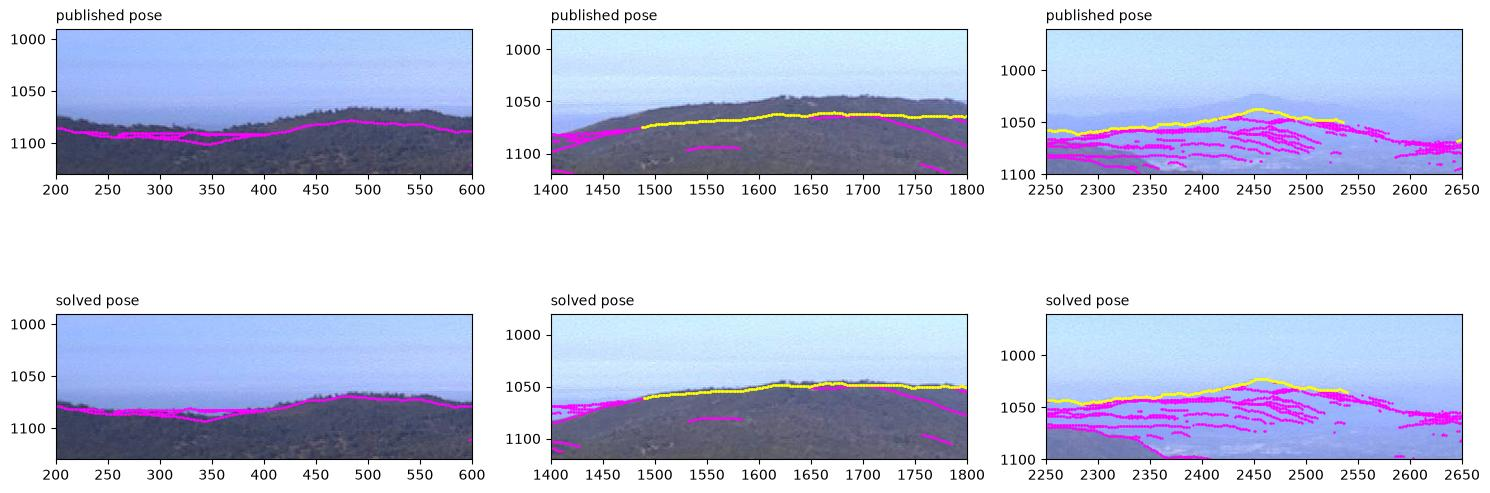

In [16]:
def project(c, az, el, pose=None):
    # Pixel coordinates of directions: through the solved pose and lens, or the published pose and shared lens.
    if pose is None:
        c = {**c, "cx": 0.0, "cy": 0.0}
        kw = dict(k_scale=fisheye.K_RATIO * fisheye.initial_k(c, W), k1=fisheye.K1)
    else:
        kw = dict(d_az=pose["d_az"], d_pitch=pose["d_pitch"], d_roll=pose["d_roll"],
                  k_scale=pose["k_ratio"] * fisheye.initial_k(c, W), k1=pose["k1"])
    x, y = fisheye.project_fisheye(c, az, el, W, H, **kw)
    return x * W, y * H


views = {"published pose": project(cam, crest_az, crest_el),
         "solved pose": project(cam_c, crest_az, crest_el, r["pose"])}
windows = [(400, 1060), (1600, 1050), (2450, 1030)]      # (x, y) centres: near ridges, mid-frame, Santiago Peak
fig, axes = plt.subplots(2, len(windows), figsize=(15, 6.5))
for row, (label, (x, y)) in enumerate(views.items()):
    for col, (x0, y0) in enumerate(windows):
        ax = axes[row, col]
        ax.imshow(cv2.cvtColor(day, cv2.COLOR_BGR2RGB))
        m = (x > x0 - 200) & (x < x0 + 200)
        ax.plot(x[m & ~is_sky], y[m & ~is_sky], ".", ms=1.5, color="magenta")
        ax.plot(x[m & is_sky], y[m & is_sky], ".", ms=2, color="yellow")
        ax.set_xlim(x0 - 200, x0 + 200)
        ax.set_ylim(y0 + 70, y0 - 70)
        ax.set_title(label, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

To put a number on it, score each pose by how strongly its crests sit on edges that are
bright above and dark below, which is what terrain against sky or haze looks like. Then shift
every crest up or down together and see where the score peaks. A right pose peaks near zero.
The peak's position is how far the terrain's edges sit from where the pose puts them.

This mostly tests pitch and roll. Ridges run roughly level, so they hold the vertical tightly
but say little about a small sideways shift. Azimuth is what the landmarks and the stars pin.

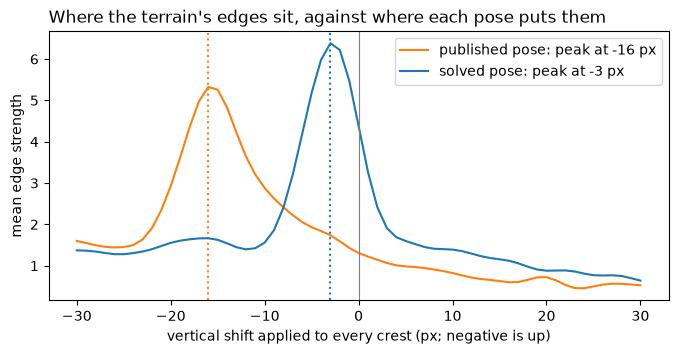

In [17]:
g = cv2.GaussianBlur(cv2.cvtColor(day, cv2.COLOR_BGR2GRAY).astype(np.float32), (0, 0), 1.5)
edge = np.zeros_like(g)
edge[1:-1] = g[:-2] - g[2:]                              # bright above minus dark below


def score(x, y, dy):
    ok = np.isfinite(x)
    xi, yi = np.round(x[ok]).astype(int), np.round(y[ok] + dy).astype(int)
    m = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
    return edge[yi[m], xi[m]].mean()


shifts = np.arange(-30, 31)
fig, ax = plt.subplots(figsize=(8, 3.5))
for (label, (x, y)), colour in zip(views.items(), ("tab:orange", "tab:blue")):
    s = np.array([score(x, y, dy) for dy in shifts])
    best = shifts[s.argmax()]
    ax.plot(shifts, s, color=colour, label=f"{label}: peak at {best:+d} px")
    ax.axvline(best, color=colour, ls=":")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("vertical shift applied to every crest (px; negative is up)")
ax.set_ylabel("mean edge strength")
ax.set_title("Where the terrain's edges sit, against where each pose puts them", loc="left")
ax.legend()
plt.show()

The solved pose puts the crests about 3 px (0.1°) from the terrain's edges, across the whole
width of the frame. The published pose puts them 16 px, about half a degree, low: the same
pitch the landmarks showed. This notebook doesn't explain the remaining 3 px. Likely sources
are the camera's height (the table's 20 m mast: for a ridge 3 km away, 10 m of height is
0.2°), the surface model's trees and buildings, and the day's refraction.

## 10. Using the pose: a pixel's bearing

The point of all this is to turn a pixel into a direction in the world, for example the
foot of a smoke column. `unproject_fisheye` is the exact inverse of the projection above.

In [18]:
def bearing(x, y, c=cam_c, pose=r["pose"]):
    az, el = fisheye.unproject_fisheye(
        c, x / W, y / H, W, H, d_az=pose["d_az"], d_pitch=pose["d_pitch"], d_roll=pose["d_roll"],
        k_scale=pose["k_ratio"] * fisheye.initial_k(c, W), k1=pose["k1"])
    return float(az), float(el)


for x, y in [(W / 2, H / 2), (100, H / 2), (W - 100, H / 2)]:
    print(f"pixel ({x:6.0f}, {y:6.0f}) -> azimuth {bearing(x, y)[0]:7.2f} deg, elevation {bearing(x, y)[1]:+6.2f} deg")

pixel (  1536,   1024) -> azimuth  269.94 deg, elevation  -0.45 deg
pixel (   100,   1024) -> azimuth  219.65 deg, elevation  -0.20 deg
pixel (  2972,   1024) -> azimuth  320.34 deg, elevation  -0.42 deg


A graticule drawn through the solved pose and lens shows what the lens does: lines of
constant azimuth bow outward toward the frame's edges, and lines of constant elevation curve.
The 0° line runs above the distant horizon: the camera is 1.9 km up, so the horizon is below
level.

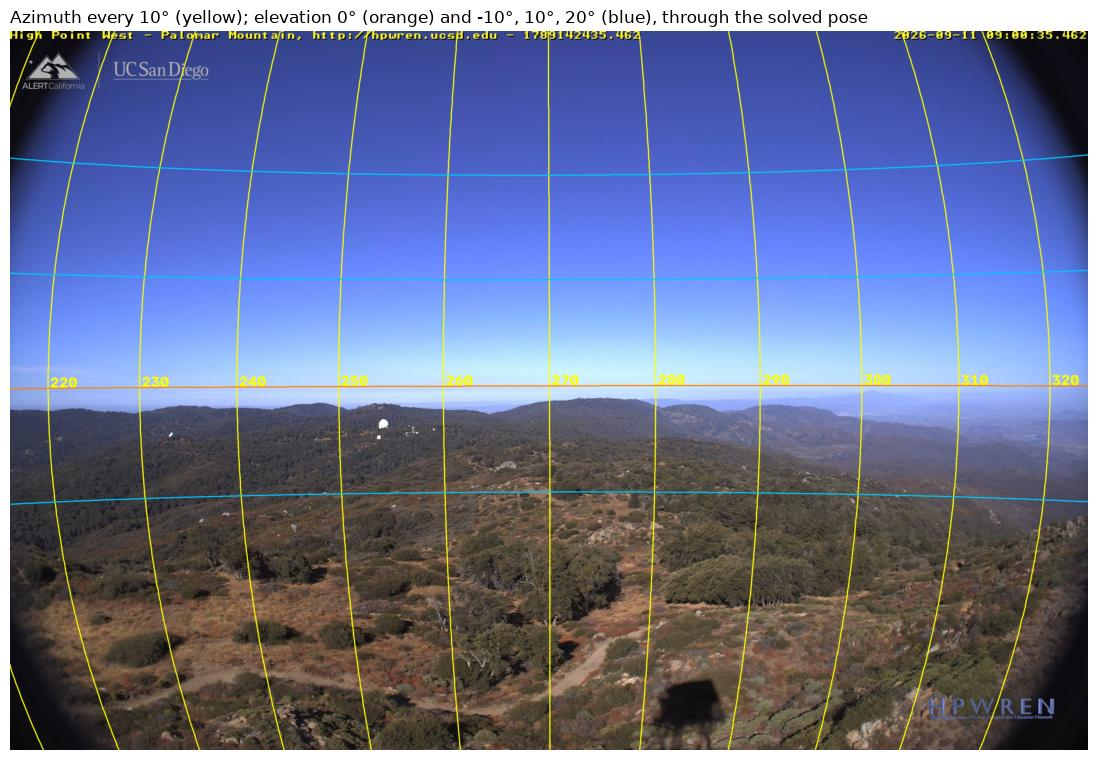

In [19]:
canvas = day.copy()
kw = dict(d_az=r["pose"]["d_az"], d_pitch=r["pose"]["d_pitch"], d_roll=r["pose"]["d_roll"],
          k_scale=r["pose"]["k_ratio"] * fisheye.initial_k(cam_c, W), k1=r["pose"]["k1"])
heading = cam["az"] + r["pose"]["d_az"]
for a in np.arange(np.ceil((heading - 60) / 10) * 10, heading + 60, 10):
    els = np.linspace(-40, 40, 200)
    x, y = fisheye.project_fisheye(cam_c, np.full_like(els, a), els, W, H, **kw)
    ok = np.isfinite(x)
    pts = np.stack([x[ok] * W, y[ok] * H], 1).astype(np.int32)
    cv2.polylines(canvas, [pts], False, (0, 255, 255), 2, cv2.LINE_AA)
    if ok.any():
        i = np.argmin(np.abs(els[ok]))
        cv2.putText(canvas, f"{a % 360:.0f}", (int(pts[i, 0]) + 6, int(pts[i, 1]) - 8), 0, 1.4, (0, 255, 255), 3)
for e in (-10, 0, 10, 20):
    azs = np.linspace(heading - 70, heading + 70, 400)
    x, y = fisheye.project_fisheye(cam_c, azs, np.full_like(azs, e), W, H, **kw)
    ok = np.isfinite(x)
    pts = np.stack([x[ok] * W, y[ok] * H], 1).astype(np.int32)
    cv2.polylines(canvas, [pts], False, (255, 200, 0) if e else (0, 128, 255), 2, cv2.LINE_AA)
show(canvas, "Azimuth every 10° (yellow); elevation 0° (orange) and -10°, 10°, 20° (blue), through the solved pose", width=14)

## Where next

- `python -m star_calibration.hpwren.calibrate fetch|solve|agree` runs the same steps over
  many cameras and nights, with cached tracks, overlays and a summary. See
  `src/star_calibration/hpwren/README.md`.
- `docs/records.md` describes every field of a solve result and of the pose ledger.
- `star_calibration.ledger` decides whether a pose measured on one date applies to another.
  Cameras get serviced and re-aimed.

Camera frames: HPWREN, <https://www.hpwren.ucsd.edu/>.